In [1]:
"""
Step 5: Evaluate best EfficientNet-B2 model on test set.
Jupyter-friendly. Paste as a new cell (can reuse imports if already run).
"""
 
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score

In [2]:
# ==================== CONFIG ====================
CODE_DIR = Path(r"D:\B.Tech\CE-AI\Sem 7\MP\Code work")
IMG_SIZE = 260
BATCH_SIZE = 16
NUM_WORKERS = 0
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
 
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
 
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

Using device: cuda


In [3]:
class BreedDataset(Dataset):
    def __init__(self, csv_path, class_to_idx, transform=None):
        self.df = pd.read_csv(csv_path)
        self.class_to_idx = class_to_idx
        self.transform = transform
 
    def __len__(self):
        return len(self.df)
 
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["filepath"]).convert("RGB")
        label = self.class_to_idx[row["label"]]
        if self.transform:
            image = self.transform(image)
        return image, label

In [4]:
# ==================== LOAD BEST MODEL ====================
checkpoint = torch.load(CODE_DIR / "best_model_v2_effnetb2.pth", map_location=DEVICE)
classes = checkpoint["classes"]
NUM_CLASSES = len(classes)
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}
idx_to_class = {idx: cls for cls, idx in class_to_idx.items()}
 
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}, val_acc={checkpoint['val_acc']:.4f}")
 
model = models.efficientnet_b2(weights=None)
in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)
model.eval()

Loaded checkpoint from epoch 19, val_acc=0.8110


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [5]:
# ==================== TEST SET ====================
test_dataset = BreedDataset(CODE_DIR / "test_v2.csv", class_to_idx, transform=eval_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
print(f"Test samples: {len(test_dataset)}")

Test samples: 2090


In [6]:
# ==================== RUN INFERENCE ====================
all_preds, all_labels, all_probs = [], [], []
 
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)
 
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
 
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

C:\Users\Mahipal\.conda\envs\tf_gpu\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [7]:
# ==================== METRICS ====================
test_acc = (all_preds == all_labels).mean()
top3_acc = top_k_accuracy_score(all_labels, all_probs, k=3, labels=np.arange(NUM_CLASSES))
top5_acc = top_k_accuracy_score(all_labels, all_probs, k=5, labels=np.arange(NUM_CLASSES))
 
print(f"\n{'='*50}")
print(f"Test Accuracy (Top-1): {test_acc:.4f}")
print(f"Test Accuracy (Top-3): {top3_acc:.4f}")
print(f"Test Accuracy (Top-5): {top5_acc:.4f}")
print(f"{'='*50}")


Test Accuracy (Top-1): 0.8096
Test Accuracy (Top-3): 0.9311
Test Accuracy (Top-5): 0.9598


In [8]:
# ---- Per-class classification report ----
target_names = [idx_to_class[i] for i in range(NUM_CLASSES)]
report = classification_report(all_labels, all_preds, target_names=target_names,
                                 digits=3, zero_division=0)
print("\nPer-class classification report:\n")
print(report)
 
report_path = CODE_DIR / "classification_report_v2.txt"
with open(report_path, "w") as f:
    f.write(f"Test Accuracy (Top-1): {test_acc:.4f}\n")
    f.write(f"Test Accuracy (Top-3): {top3_acc:.4f}\n")
    f.write(f"Test Accuracy (Top-5): {top5_acc:.4f}\n\n")
    f.write(report)
print(f"Saved classification report to: {report_path}")


Per-class classification report:

                          precision    recall  f1-score   support

        buffalo_alambadi      0.981     1.000     0.990        52
           buffalo_banni      0.788     0.839     0.812        31
          buffalo_bargur      0.364     0.148     0.211        27
       buffalo_bhadawari      0.756     0.886     0.816        35
     buffalo_jaffarabadi      1.000     0.906     0.951        32
         buffalo_mehsana      0.686     0.889     0.774        27
          buffalo_murrah      0.809     0.745     0.776        51
         buffalo_nagpuri      0.846     0.717     0.776        46
       buffalo_nili_ravi      0.826     0.792     0.809        24
           buffalo_surti      0.667     0.941     0.780        17
            buffalo_toda      0.647     0.611     0.629        18
       cattle_amritmahal      0.769     0.930     0.842        43
         cattle_ayrshire      0.932     0.872     0.901        94
          cattle_bachaur      0.571     

Saved confusion matrix to: D:\B.Tech\CE-AI\Sem 7\MP\Code work\confusion_matrix_v2.png


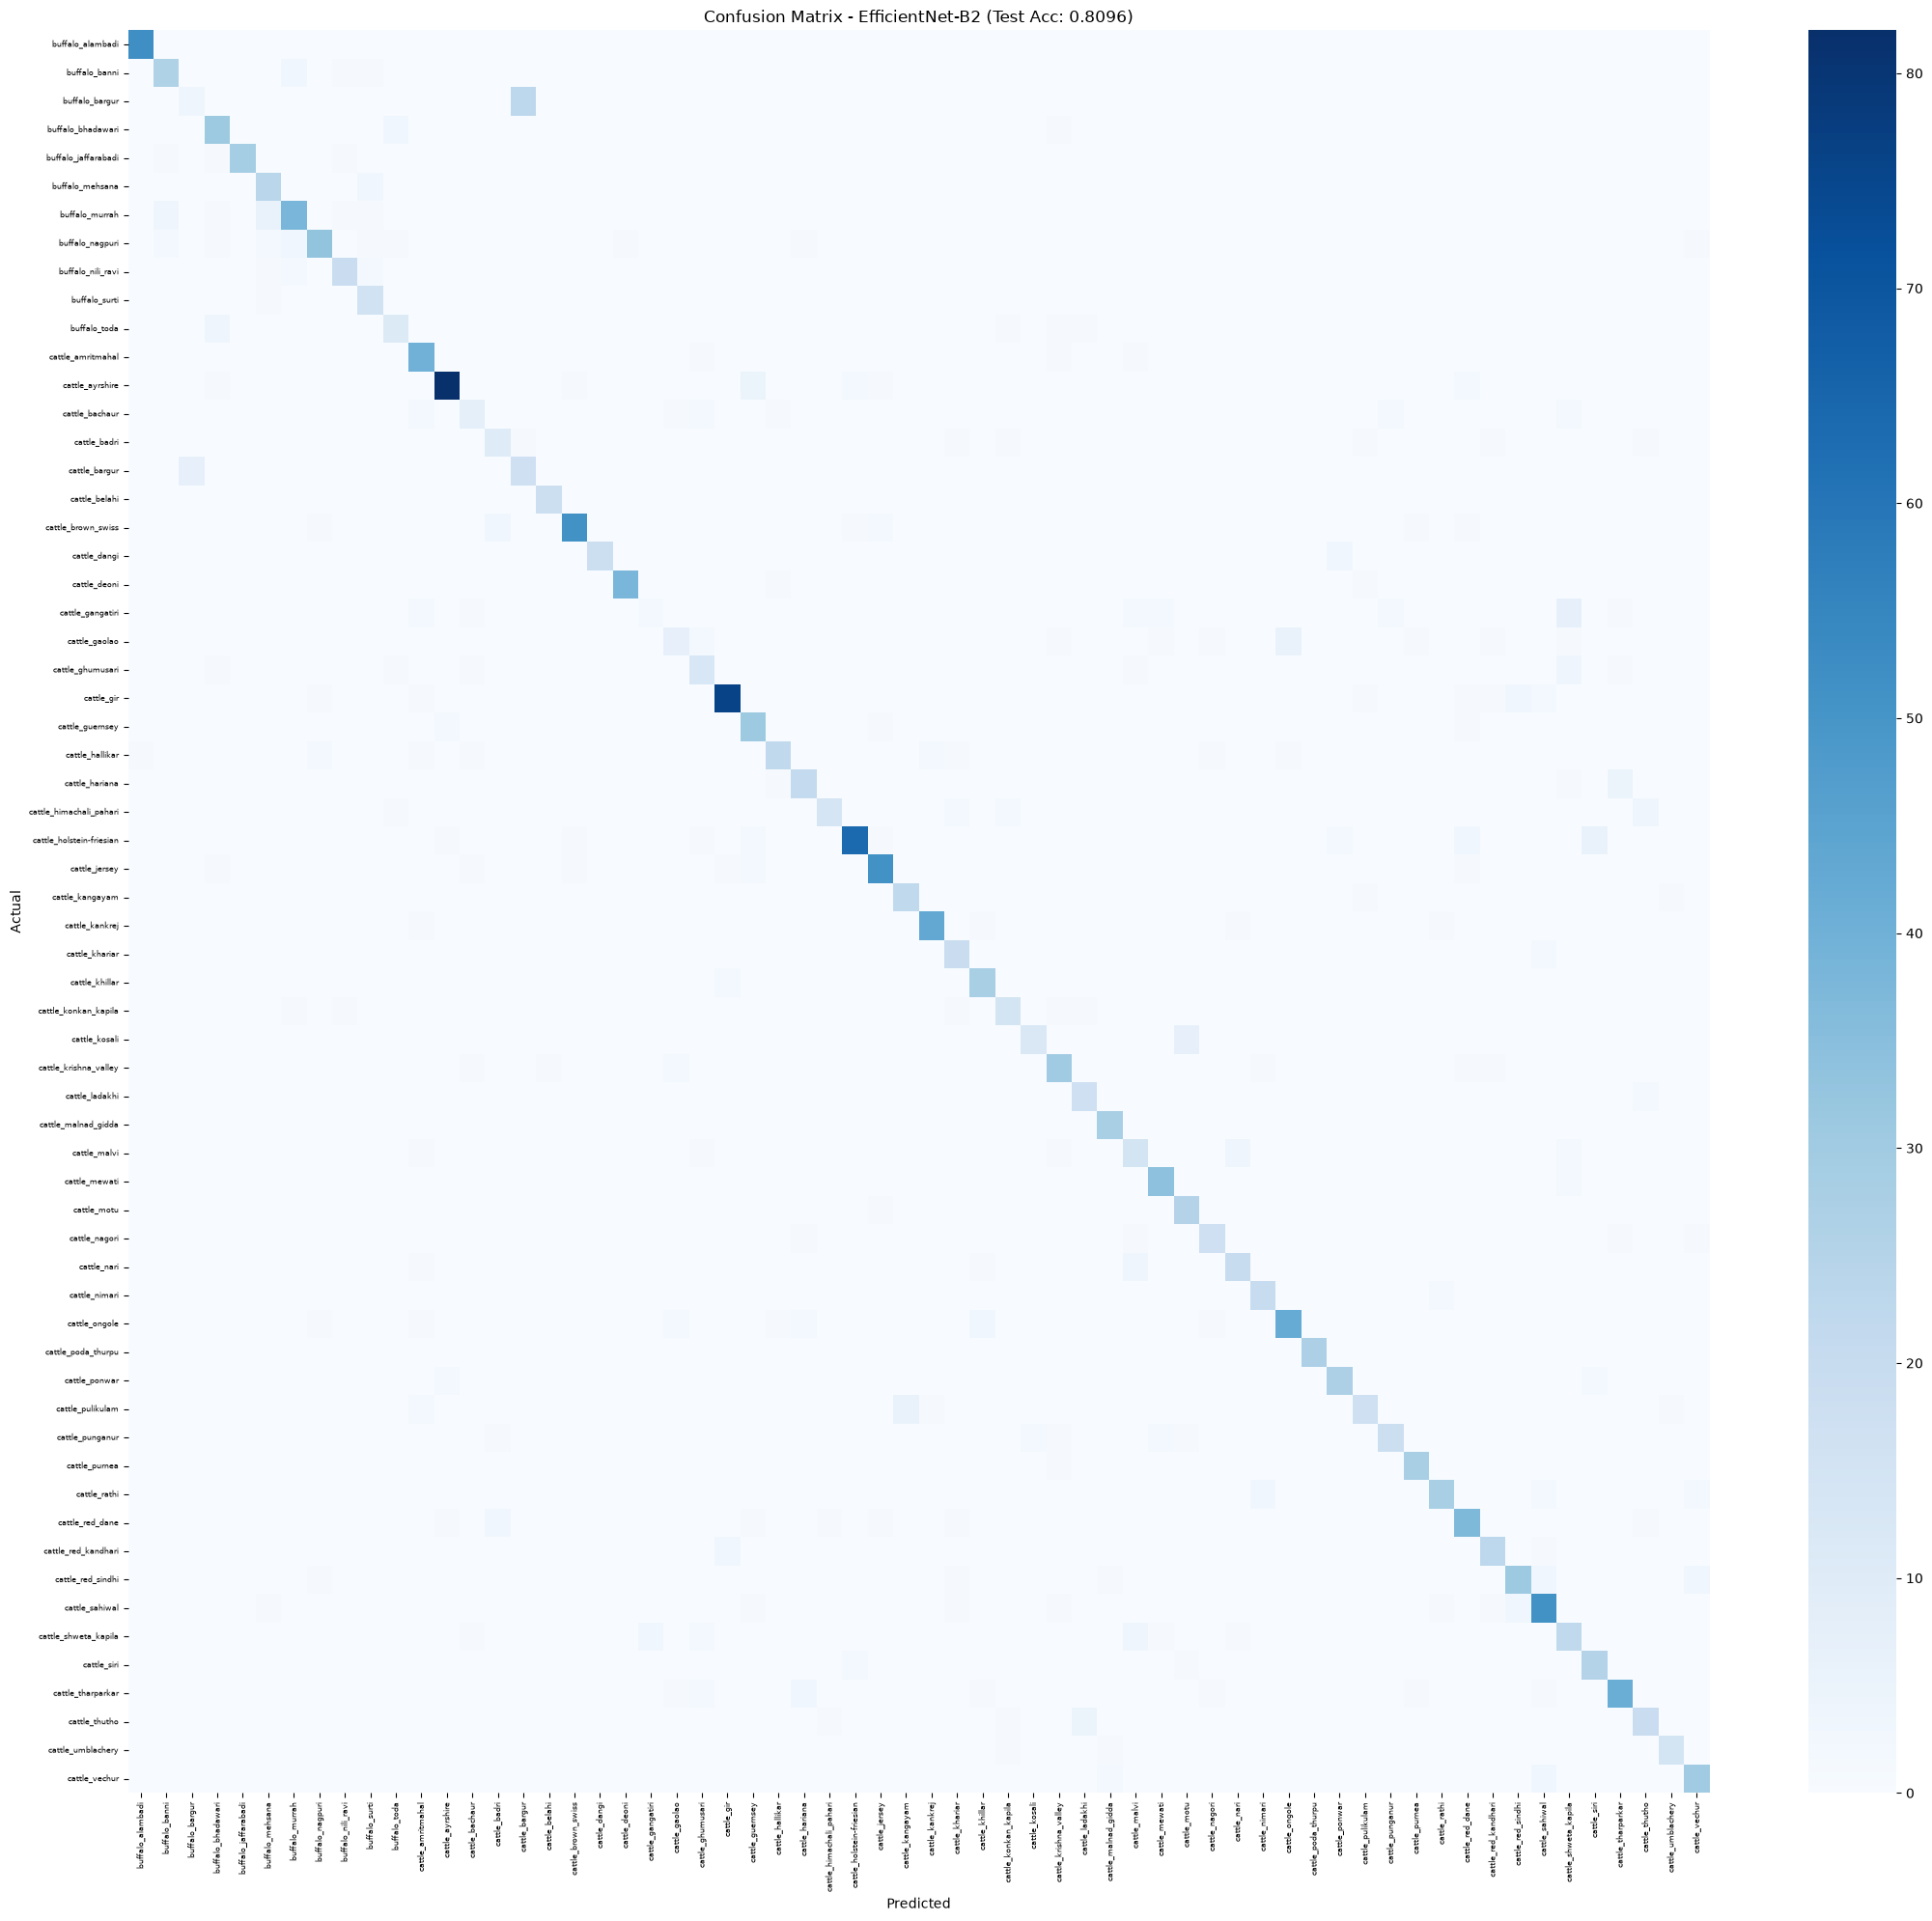

In [9]:
# ==================== CONFUSION MATRIX ====================
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(22, 20))
sns.heatmap(cm, annot=False, cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - EfficientNet-B2 (Test Acc: {test_acc:.4f})")
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
cm_path = CODE_DIR / "confusion_matrix_v2.png"
plt.savefig(cm_path, dpi=150)
print(f"Saved confusion matrix to: {cm_path}")
plt.show()

In [10]:
# ==================== WORST & BEST PERFORMING CLASSES ====================
from sklearn.metrics import precision_recall_fscore_support
 
precision, recall, f1, support = precision_recall_fscore_support(
    all_labels, all_preds, labels=np.arange(NUM_CLASSES), zero_division=0
)
per_class_df = pd.DataFrame({
    "class": target_names,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "support": support
}).sort_values("f1_score")
 
print("\n--- 10 Worst Performing Classes (by F1) ---")
print(per_class_df.head(10).to_string(index=False))
 
print("\n--- 10 Best Performing Classes (by F1) ---")
print(per_class_df.tail(10).to_string(index=False))
 
per_class_df.to_csv(CODE_DIR / "per_class_metrics_v2.csv", index=False)
print(f"\nSaved per-class metrics to: {CODE_DIR / 'per_class_metrics_v2.csv'}")


--- 10 Worst Performing Classes (by F1) ---
               class  precision   recall  f1_score  support
    cattle_gangatiri   0.400000 0.105263  0.166667       19
      buffalo_bargur   0.363636 0.148148  0.210526       27
       cattle_gaolao   0.538462 0.333333  0.411765       21
      cattle_bachaur   0.571429 0.444444  0.500000       18
       cattle_bargur   0.414634 0.708333  0.523077       24
    cattle_ghumusari   0.541667 0.590909  0.565217       22
        cattle_malvi   0.535714 0.625000  0.576923       24
cattle_shweta_kapila   0.536585 0.647059  0.586667       34
        cattle_badri   0.588235 0.625000  0.606061       16
        buffalo_toda   0.647059 0.611111  0.628571       18

--- 10 Best Performing Classes (by F1) ---
              class  precision   recall  f1_score  support
         cattle_gir   0.926829 0.883721  0.904762       86
       cattle_dangi   1.000000 0.857143  0.923077       21
     cattle_kankrej   0.934783 0.914894  0.924731       47
cattle_malnad_g